# 4.2 — Mean, Variance, Std, at the computer

Do the **pen-and-paper worksheet first**. Here you check your hand work, then do the same job
at ML scale — and see with your own eyes why unnormalised features break things.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. The five steps, longhand then one-liners

The lesson's worked example, with every named step visible — then numpy doing it in three calls.

In [2]:
x = np.array([2, 4, 4, 4, 5, 5, 7, 9])

mu = x.sum() / len(x)          # CENTRE      (len(x) = how many values)
devs = x - mu                  # DEVIATIONS  (numpy subtracts mu from EVERY element at once)
sq = devs**2                   # SQUARE
var = sq.sum() / len(x)        # AVERAGE
std = np.sqrt(var)             # UNSQUARE

print("deviations:", devs, "  (sum:", devs.sum(), "— always 0!)")
print("mu =", mu, "  var =", var, "  std =", std)

# numpy's shortcuts — same numbers or we riot:
print("numpy says:", x.mean(), x.var(), x.std())

deviations: [-3. -1. -1. -1.  0.  0.  2.  4.]   (sum: 0.0 — always 0!)
mu = 5.0   var = 4.0   std = 2.0
numpy says: 5.0 4.0 2.0


## 2. See the problem normalisation fixes

Two features for 500 people: **income** (tens of thousands) and **height** (around 178).
Same people, wildly different scales. Watch what the raw picture looks like:

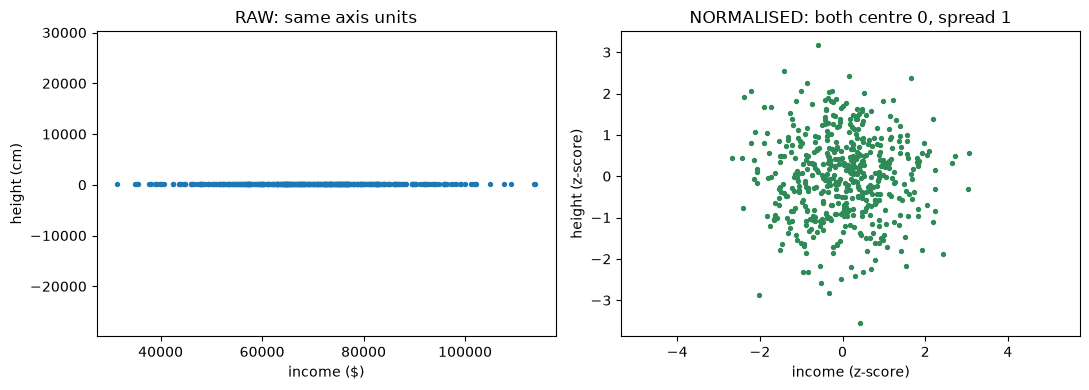

raw spreads:         14385.0 vs 7.1
normalised spreads:  1.0 vs 1.0


In [3]:
# rng.normal(centre, spread, size) draws bell-curve numbers — formally introduced in 4.3;
# today it's just a realistic data factory.
income = rng.normal(70_000, 15_000, size=500)   # dollars
height = rng.normal(178, 7, size=500)           # centimetres

# plt.subplots(1, 2) = one row, two plot panels side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.scatter(income, height, s=8)
ax1.set_xlabel("income ($)"); ax1.set_ylabel("height (cm)")
ax1.set_title("RAW: same axis units")
ax1.axis("equal")               # force equal scaling — this is how a network 'sees' raw numbers

z_income = (income - income.mean()) / income.std()   # every value -> its z-score
z_height = (height - height.mean()) / height.std()
ax2.scatter(z_income, z_height, s=8, color="seagreen")
ax2.set_xlabel("income (z-score)"); ax2.set_ylabel("height (z-score)")
ax2.set_title("NORMALISED: both centre 0, spread 1")
ax2.axis("equal")

plt.tight_layout()
plt.show()

print("raw spreads:        ", income.std().round(0), "vs", height.std().round(1))
print("normalised spreads: ", z_income.std().round(3), "vs", z_height.std().round(3))

Left plot: height is a **flat line** — its entire human variation is invisible next to income's
scale. A network fed these raw numbers effectively can't see height at all, and gradient descent
gets yanked around by whichever feature shouts loudest.

Right plot: after z-scoring, both features speak at the same volume. *That* is why every ML
pipeline normalises — and 4.2's two numbers, $\mu$ and $\sigma$, are all it took.

## 3. Your turn

In [4]:
# YOUR TURN
#
# a) Worksheet Part D check — PREDICT each answer aloud BEFORE running:
y = np.array([1., 2., 6., 7.])
print("original:   mu =", y.mean(), " std =", y.std())
print("+10 to all: mu =", (y + 10).mean(), " std =", (y + 10).std())    # predicted?
# print("x3 to all:  mu =", ..., " std =", ...)                          # your line — and check var too!

# b) Normalise this feature to centre 0, spread 1, then PROVE it with .mean() and .std():
prices = rng.normal(650_000, 150_000, size=1_000)
# z = ...
# print(z.mean(), z.std())

# c) Sanity puzzle: what are np.array([7, 7, 7]).std() and .var()? Guess, then run.

original:   mu = 4.0  std = 2.5495097567963922
+10 to all: mu = 14.0  std = 2.5495097567963922


## 4. What you now own

$\mu$ says *where the data sits*, $\sigma$ says *how loudly it varies*, and
$z = \frac{x - \mu}{\sigma}$ puts every feature on the same scale. Inside real networks,
**batch norm** layers do this exact computation on the fly, mid-network, millions of times per
training run. You just did the math of one of deep learning's workhorse layers.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 4.3 — the bell curve,
born from chaos in front of you.*